In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm

from scipy.stats import chi2, vonmises
from sklearn.metrics import pairwise_distances

from nystroem_ksd.ksd import DirectionalKSD, TestBenchmark, NystroemDirectionalKSD, Rayleigh, ContextTimer, UniformCircle, VonMises, get_sns_conf, VonMisesFisher3d,  UniformSphere3d

In [2]:
level_alpha = 0.01

In [3]:
rng = np.random.default_rng(1234)

In [4]:
## Replicate 6.1 in https://arxiv.org/pdf/2002.06843

In [5]:
optim_kappa_param = 0.12 # obtained below

In [6]:
ns = [30,50,100,200]
data = { "Uniform" : UniformCircle(),
         "VonMises" : VonMises()
       }

tests = { "Rayleigh" : Rayleigh(level_alpha=level_alpha),
          "N-KSD" : NystroemDirectionalKSD(kappa=optim_kappa_param, d=2, level_alpha=level_alpha),
          "KSD" : DirectionalKSD(kappa=optim_kappa_param, d=2, level_alpha=level_alpha)
        }

res = pd.DataFrame()
for n in tqdm(ns):
    for data_key, data_value in data.items():
        for test_key, test_value in tests.items():
            with ContextTimer() as t:
                rejects = TestBenchmark(stat_test=test_value).error(n=n,data_gen=data_value.gen, repetitions=600) # use 600 for final
            res = pd.concat((res,pd.DataFrame({
                "n" : [n],
                "data" : [data_key],
                "test" : [test_key],
                "rejects" : [rejects],
                "time" : [t.secs]
            })))

100%|████████████████████████████████████████████| 4/4 [09:52<00:00, 148.06s/it]


In [7]:
res.head()

,n,data,test,rejects,time
0,30,Uniform,Rayleigh,0.005000,0.088830
0,30,Uniform,N-KSD,0.008333,12.578646
0,30,Uniform,KSD,0.015000,11.136093
0,30,VonMises,Rayleigh,0.158333,0.106092
0,30,VonMises,N-KSD,0.170000,12.454769


In [8]:
res.to_csv("../results/directional-ksd-d2.csv")

Optimize parameter kappa

In [ ]:
mappings = {}
n=100
for k in np.linspace(0,1,50):
    nksd = NystroemDirectionalKSD(kappa=k,level_alpha=level_alpha)
    mappings[k] =  TestBenchmark(stat_test=nksd).error(n=n,data_gen=VonMises().gen, repetitions=600)
sns.lineplot(x=list(mappings.keys()),y=list(mappings.values()))
print(max(mappings,key=mappings.get))

## 3 dimensions

In [9]:
import numpy as np
from scipy.stats import vonmises_fisher
from nystroem_ksd.ksd import UniformSphere3d, DirectionalKSD, to_angles

In [10]:
optim_kappa_param = 0.28
res3d = pd.DataFrame()

In [11]:
n = 300
kappas = np.linspace(0.01,6,10)
data = { #"Uniform" : UniformSphere3d(),
         "VonMises" : VonMisesFisher3d
       }
tests = { #"Rayleigh" : Rayleigh(level_alpha=level_alpha),
          "N-KSD" : NystroemDirectionalKSD(kappa=optim_kappa_param, d=3, level_alpha=level_alpha),
          #"KSD" : DirectionalKSD(kappa=optim_kappa_param, d=3, level_alpha=level_alpha)
        }

for kappa in tqdm(kappas):
    for data_key, data_value in data.items():
        for test_key, test_value in tests.items():
            with ContextTimer() as t:
                rejects = TestBenchmark(stat_test=test_value).error(n=n,data_gen=data_value(kappa=kappa).gen, repetitions=600)
            res3d = pd.concat((res3d,pd.DataFrame({
                "n" : [n],
                "kappa" : [kappa],
                "data" : [data_key],
                "test" : [test_key],
                "rejects" : [rejects],
                "time" : [t.secs]
            })))

100%|██████████████████████████████████████████| 10/10 [50:39<00:00, 303.94s/it]


In [12]:
res3d

,n,kappa,data,test,rejects,time
0,300,0.010000,VonMises,N-KSD,0.010000,299.729739
0,300,0.675556,VonMises,N-KSD,0.040000,298.583074
0,300,1.341111,VonMises,N-KSD,0.103333,312.388706
0,300,2.006667,VonMises,N-KSD,0.265000,286.963525
0,300,2.672222,VonMises,N-KSD,0.391667,309.451447
0,300,3.337778,VonMises,N-KSD,0.610000,305.495270
0,300,4.003333,VonMises,N-KSD,0.743333,312.074633
0,300,4.668889,VonMises,N-KSD,0.833333,315.308627
0,300,5.334444,VonMises,N-KSD,0.896667,299.197298
0,300,6.000000,VonMises,N-KSD,0.951667,300.229010


In [13]:
ns = [30,50,100,200]
data = { "Uniform" : UniformSphere3d(),
         #"VonMises" : VonMisesFisher3d
       }
tests = { #"Rayleigh" : Rayleigh(level_alpha=level_alpha),
          "N-KSD" : NystroemDirectionalKSD(kappa=optim_kappa_param, d=3, level_alpha=level_alpha),
          #"KSD" : DirectionalKSD(kappa=optim_kappa_param, d=3, level_alpha=level_alpha)
        }

for n in tqdm(ns):
    for data_key, data_value in data.items():
        for test_key, test_value in tests.items():
            with ContextTimer() as t:
                rejects = TestBenchmark(stat_test=test_value).error(n=n,data_gen=data_value.gen, repetitions=600)
            res3d = pd.concat((res3d,pd.DataFrame({
                "n" : [n],
                "kappa" : [0],
                "data" : [data_key],
                "test" : [test_key],
                "rejects" : [rejects],
                "time" : [t.secs]
            })))

100%|█████████████████████████████████████████████| 4/4 [04:40<00:00, 70.03s/it]


In [14]:
res3d

,n,kappa,data,test,rejects,time
0,300,0.010000,VonMises,N-KSD,0.010000,299.729739
0,300,0.675556,VonMises,N-KSD,0.040000,298.583074
0,300,1.341111,VonMises,N-KSD,0.103333,312.388706
0,300,2.006667,VonMises,N-KSD,0.265000,286.963525
0,300,2.672222,VonMises,N-KSD,0.391667,309.451447
0,300,3.337778,VonMises,N-KSD,0.610000,305.495270
0,300,4.003333,VonMises,N-KSD,0.743333,312.074633
0,300,4.668889,VonMises,N-KSD,0.833333,315.308627
0,300,5.334444,VonMises,N-KSD,0.896667,299.197298
0,300,6.000000,VonMises,N-KSD,0.951667,300.229010


In [15]:
res3d.to_csv("../results/directional-ksd-d3.csv")

Optimize parameter kappa

100%|███████████████████████████████████████████| 50/50 [09:24<00:00, 11.29s/it]


0.280072


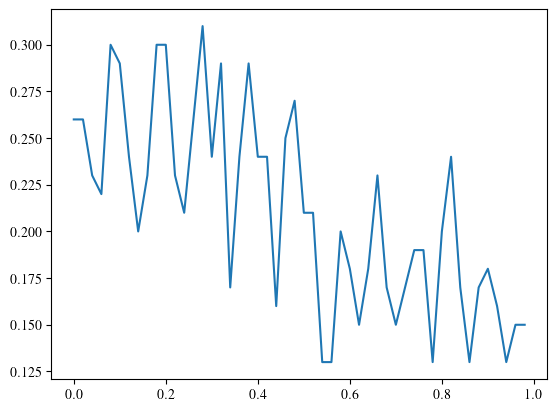

In [11]:
mappings = {}
n=100
for k in tqdm(np.linspace(0.0001,1,50,endpoint=False)):
    nksd = NystroemDirectionalKSD(kappa=k, d=3, level_alpha=level_alpha)
    mappings[k] =  TestBenchmark(stat_test=nksd).error(n=n,data_gen=VonMisesFisher3d(kappa=2).gen, repetitions=100)
sns.lineplot(x=list(mappings.keys()),y=list(mappings.values()))
print(max(mappings,key=mappings.get))

In [123]:
from scipy.stats import vonmises_fisher
from nystroem_ksd.ksd import to_angles

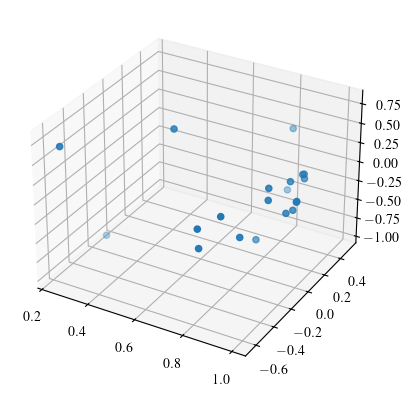

In [124]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
# Define sphere parameters
r = 1
t1, t2 = X[:,0], X[:,1]
# Convert to Cartesian coordinates
x = r * np.sin(t1)
y = r * np.cos(t1) * np.sin(t2)
z = r * np.cos(t1) * np.cos(t2)
#x,y,z = X[:,0],X[:,1],X[:,2]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z)
plt.show()